# Exercise 3

## Imports

In [84]:
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform
from rasterio.windows import from_bounds
import spectral.io.envi as envi
from pystac_client import Client
from pyproj import Transformer
import planetary_computer

# Set acquisition date
ACQUISITION_DATE = '2025-06-17'

# Relative path to airborne data
BASE_DIR = Path().cwd() / "lab_5" / "data" / "you-shall-not-pass" / "Obrazy lotnicze"
hdr_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'
bsq_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.bsq'

print(f"Target Date: {ACQUISITION_DATE}")
print(f"Airborne Data Path: {bsq_path}")

Target Date: 2025-06-17
Airborne Data Path: E:\github_repos\eolabs\lab_5\data\you-shall-not-pass\Obrazy lotnicze\221000_Odra_HS_Blok_A_008_VS_join_atm.bsq


## Load Airborne data

A few quick fixes

In [85]:
# del os.environ["PROJ_LIB"]

In [86]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [87]:
# !pip uninstall rasterio pyproj -y
!pip install rasterio pyproj

In [88]:
if not hdr_path.exists():
    raise FileNotFoundError(f"Cannot find airborne data at {hdr_path}")

img = envi.open(hdr_path)
meta = img.metadata
wavelengths = np.array([float(x) for x in meta['wavelength']])

# Read a subset (1000x1000) from the center to keep memory usage low
cy, cx = img.nrows // 2, img.ncols // 2
cube = img.read_subregion((cy-500, cy+500), (cx-500, cx+500))

# Extract geographic bounds of the subset using the .bsq file for rasterio
with rasterio.open(bsq_path) as src:
    air_win = rasterio.windows.Window(cx-500, cy-500, 1000, 1000)
    air_left, air_bottom, air_right, air_top = src.window_bounds(air_win)
    lons, lats = transform(src.crs, 'EPSG:4326', [air_left, air_right], [air_bottom, air_top])
    # got a whole lot of PROJ exceptions here, but that's the bbox that will be used for Sentinel 2 data
    subset_bbox = [lons[0], lats[0], lons[1], lats[1]]

print(f"Loaded subset shape: {cube.shape}")

Loaded subset shape: (1000, 1000, 456)


## Show airborne data

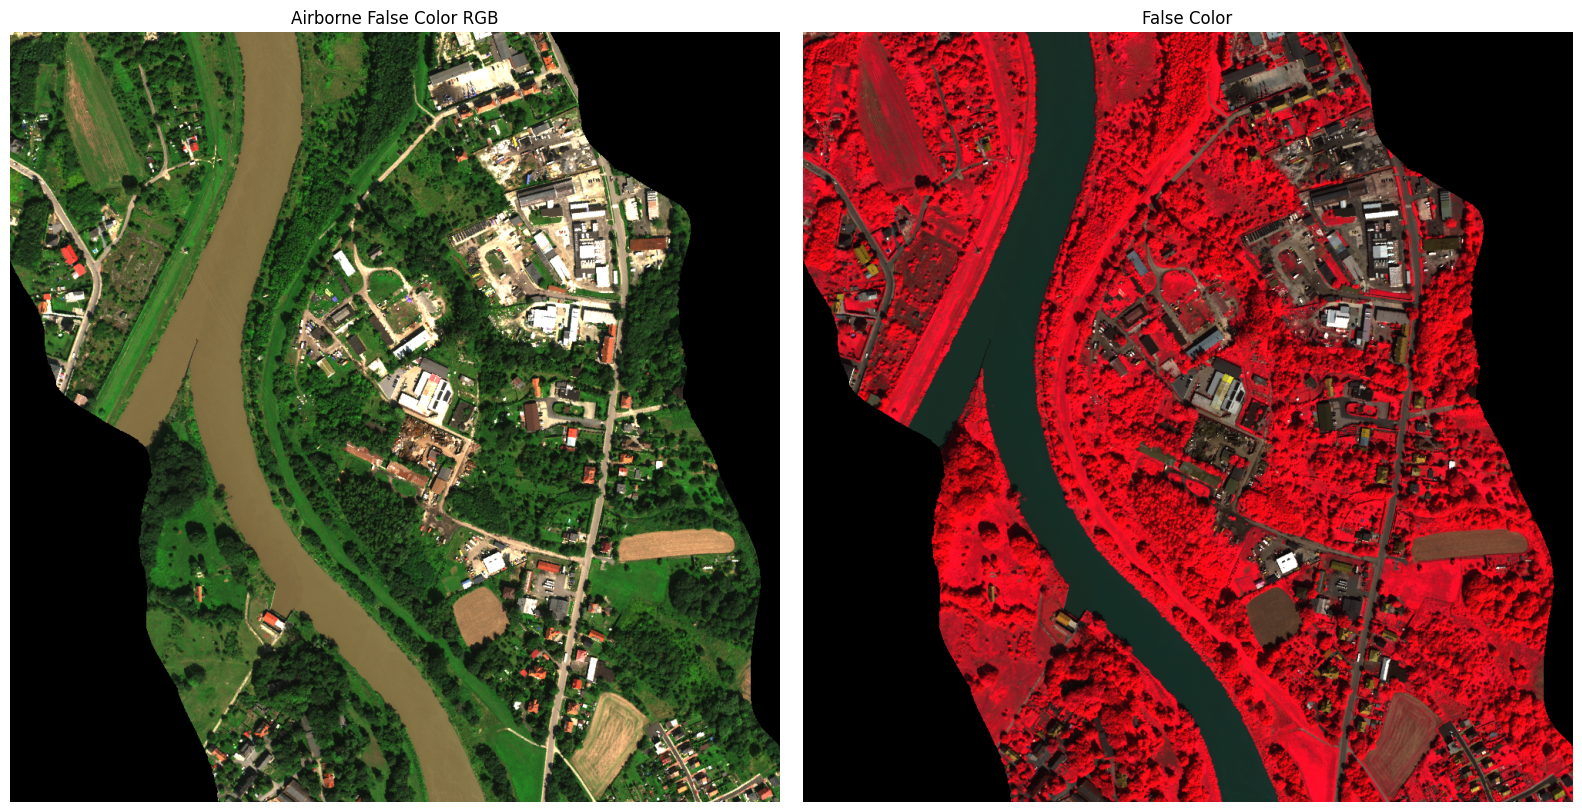

In [89]:
r_idx = np.argmin(np.abs(wavelengths - 670))
g_idx = np.argmin(np.abs(wavelengths - 560))
b_idx = np.argmin(np.abs(wavelengths - 490))

rgb_air = cube[:, :, [r_idx, g_idx, b_idx]]
# cut outliers
rgb_air = (rgb_air - np.percentile(rgb_air, 2)) / (np.percentile(rgb_air, 98) - np.percentile(rgb_air, 2))
rgb_air = np.clip(rgb_air, 0, 1)

# show false color
nir_idx = np.argmin(np.abs(wavelengths - 858))
r2_idx  = np.argmin(np.abs(wavelengths - 663))
g2_idx  = np.argmin(np.abs(wavelengths - 551))

rgb_nir = cube[:, :, [nir_idx, r2_idx, g2_idx]]
rgb_nir = (rgb_nir - np.percentile(rgb_nir, 2)) / (np.percentile(rgb_nir, 98) - np.percentile(rgb_nir, 2))
rgb_nir = np.clip(rgb_nir, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(rgb_air)
axes[0].set_title("Airborne False Color RGB")
axes[0].axis('off')

axes[1].imshow(rgb_nir)
axes[1].set_title("False Color")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Water Quality Indices: Technical Notes

The following indices are used to estimate water constituents from spectral reflectance:

1. **Chlorophyll-a (Chl-a)**: This is the primary pigment found in phytoplankton. **Red Edge/Red ratio (705nm / 665nm)**

2. **Dissolved Organic Carbon (DOC)**: represents organic material that stains the water. **Green/Red ratio (665nm / 490nm)**

3. **Turbidity**: This measures water clarity and the presence of suspended particulate matter
    - **airborne** - **750nm** band
    - **Sentinel-2** **B11 (SWIR)** band

## Water Quality Indices (Airborne)

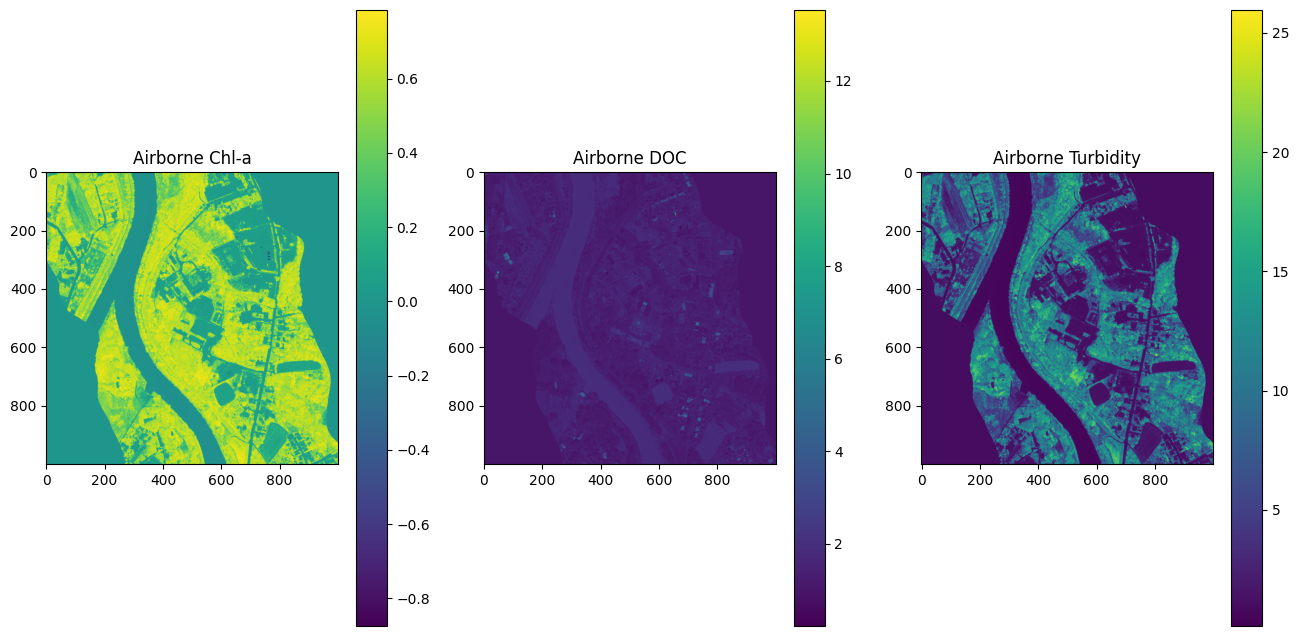

In [101]:
def safe_ratio(n, d, eps=1e-6):
    return n / (d + eps)

idx_705 = np.argmin(np.abs(wavelengths - 705))
idx_665 = np.argmin(np.abs(wavelengths - 665))
idx_490 = np.argmin(np.abs(wavelengths - 490))
idx_560 = np.argmin(np.abs(wavelengths - 560))
idx_750 = np.argmin(np.abs(wavelengths - 750))
idx_700 = np.argmin(np.abs(wavelengths - 700))

# normalized in order to amplify the difference
chla_air = safe_ratio(
    cube[:, :, idx_705] - cube[:, :, idx_665],
    cube[:, :, idx_705] + cube[:, :, idx_665]
)

doc_air = safe_ratio(cube[:, :, idx_665], cube[:, :, idx_490])
turb_air = safe_ratio(cube[:, :, idx_750], cube[:, :, idx_665])

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for i, (data, name) in enumerate(zip([chla_air, doc_air, turb_air], ['Chl-a', 'DOC', 'Turbidity'])):
    im = axes[i].imshow(data, cmap='viridis')
    axes[i].set_title(f"Airborne {name}")
    plt.colorbar(im, ax=axes[i])
plt.show()

In [91]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

## Download Sentinel-2 Data
dates around **2025-06-17**

In [92]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", 
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    datetime=ACQUISITION_DATE,
    bbox=subset_bbox, 
    query={"eo:cloud_cover": {"lt": 10}}
)

items = list(search.items())
if not items:
    print("Searching days other than the exact day")
    search = catalog.search(
        collections=["sentinel-2-l2a"], 
        bbox=subset_bbox, 
        datetime="2025-06-10/2025-06-25", 
        query={"eo:cloud_cover": {"lt": 10}}
    )
    # select smallest cloud cover
    items = sorted(list(search.items()), key=lambda x: x.properties["eo:cloud_cover"])

if not items:
    raise ValueError("No suitable cloud-free Sentinel-2 imagery found.")

best_item = items[0]
print(f"Selected Sentinel-2 Scene: {best_item.id} ({best_item.datetime.date()})")
print(f"Cloud Cover: {best_item.properties['eo:cloud_cover']:.2f}%")

assets = best_item.assets
bands_s2 = {
    'B03': assets['B03'].href, # Green
    'B04': assets['B04'].href, # Red
    'B05': assets['B05'].href, # Red Edge 1
    'B11': assets['B11'].href  # SWIR 1
}

Searching days other than the exact day
Selected Sentinel-2 Scene: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401 (2025-06-15)
Cloud Cover: 0.46%


2 days off with cloud cover 0.46% - quite fine

## Water Quality Indices (Sentinel-2)

#### Load bands for sentinel

In [ ]:
data_s2 = {}

with rasterio.open(bands_s2['B04']) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    
    minx, miny = transformer.transform(subset_bbox[0], subset_bbox[1])
    maxx, maxy = transformer.transform(subset_bbox[2], subset_bbox[3])

    s2_win = from_bounds(minx, miny, maxx, maxy, src.transform)

    # reference to reshape bands with lower resolution
    ref = src.read(1, window=s2_win).astype(float) / 10000.0
    ref_shape = ref.shape
    
    data_s2['B04'] = src.read(1, window=s2_win).astype(float) / 10000.0

with rasterio.open(bands_s2['B03']) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    
    minx, miny = transformer.transform(subset_bbox[0], subset_bbox[1])
    maxx, maxy = transformer.transform(subset_bbox[2], subset_bbox[3])

    s2_win = from_bounds(minx, miny, maxx, maxy, src.transform)

    data_s2['B03'] = src.read(1, window=s2_win).astype(float) / 10000.0

# why the resample? Well for starters without it, it failed 
# second reason is simple - the resolution is lower therefore in order to use the bands we need to operate on the "same" resolution
for band in ['B05', 'B11']:
    with rasterio.open(bands_s2[band]) as src:
        # without it the river for two indices was not visible!
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        
        minx, miny = transformer.transform(subset_bbox[0], subset_bbox[1])
        maxx, maxy = transformer.transform(subset_bbox[2], subset_bbox[3])

        s2_win = from_bounds(minx, miny, maxx, maxy, src.transform)

        data_s2[band] = src.read(
            1,
            window=s2_win,
            out_shape=ref_shape,
            resampling=rasterio.enums.Resampling.bilinear
        ).astype(float) / 10000.0

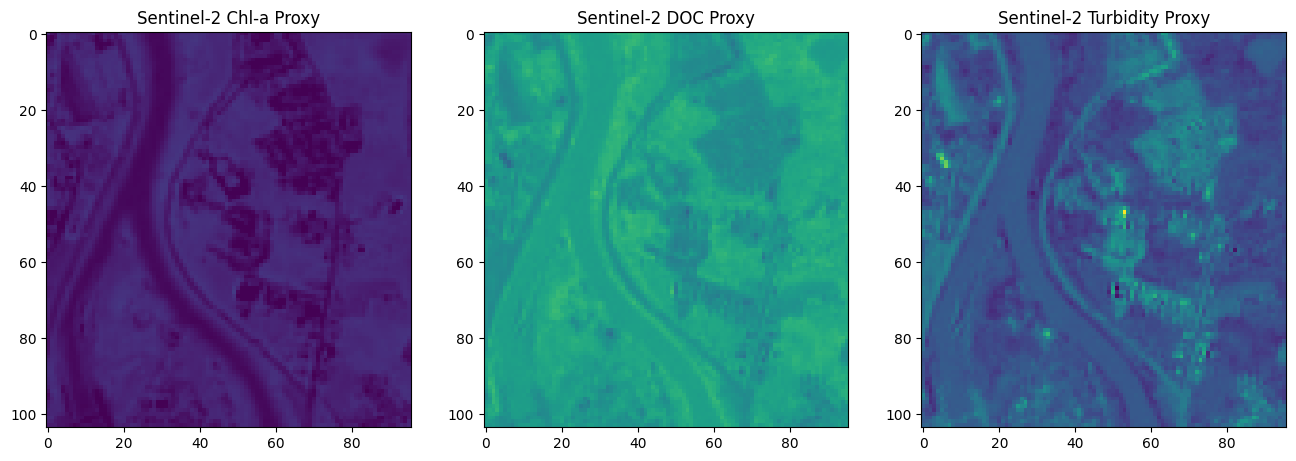

In [99]:
chla_s2 = safe_ratio(data_s2['B05'] - data_s2['B04'], data_s2['B05'] + data_s2['B04'])

doc_s2 = safe_ratio(data_s2['B03'], data_s2['B04'])
turb_s2 = data_s2['B04'] - data_s2['B03']

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes[0].imshow(chla_s2, cmap='viridis', vmin=0, vmax=2)
axes[0].set_title("Sentinel-2 Chl-a Proxy")
axes[1].imshow(doc_s2, cmap='viridis', vmin=0, vmax=2)
axes[1].set_title("Sentinel-2 DOC Proxy")
axes[2].imshow(turb_s2, cmap='viridis')
axes[2].set_title("Sentinel-2 Turbidity Proxy")
plt.show()

It's over the same area although as it can be seen most of the details are lost, for ChI-a the river is barely visible

## Compare index values

In [95]:
print(f"Airborne Chl-a: {np.nanmean(chla_air):.4f}")
print(f"Sentinel-2 Chl-a: {np.nanmean(chla_s2):.4f}")
print(f"Relative Difference (Chl-a): {abs(np.nanmean(chla_air)-np.nanmean(chla_s2))/np.nanmean(chla_air)*100:.2f}%")

print(f"\nAirborne DOC: {np.nanmean(doc_air):.4f}")
print(f"Sentinel-2 DOC: {np.nanmean(doc_s2):.4f}")
print(f"Relative Difference (DOC): {abs(np.nanmean(doc_air)-np.nanmean(doc_s2))/np.nanmean(doc_air)*100:.2f}%")

print(f"\nAirborne Turbidity: {np.nanmean(turb_air):.4f}")
print(f"Sentinel-2 Turbidity: {np.nanmean(turb_s2):.4f}")
print(f"Relative Difference (Turbidity): {abs(np.nanmean(turb_air)-np.nanmean(turb_s2))/np.nanmean(turb_air)*100:.2f}%")

Airborne Chl-a: 0.2999
Sentinel-2 Chl-a: 0.0927
Relative Difference (Chl-a): 69.09%

Airborne DOC: 1.3621
Sentinel-2 DOC: 1.1208
Relative Difference (DOC): 17.72%

Airborne Turbidity: 0.1765
Sentinel-2 Turbidity: 0.2570
Relative Difference (Turbidity): 45.63%


## Visual comparison

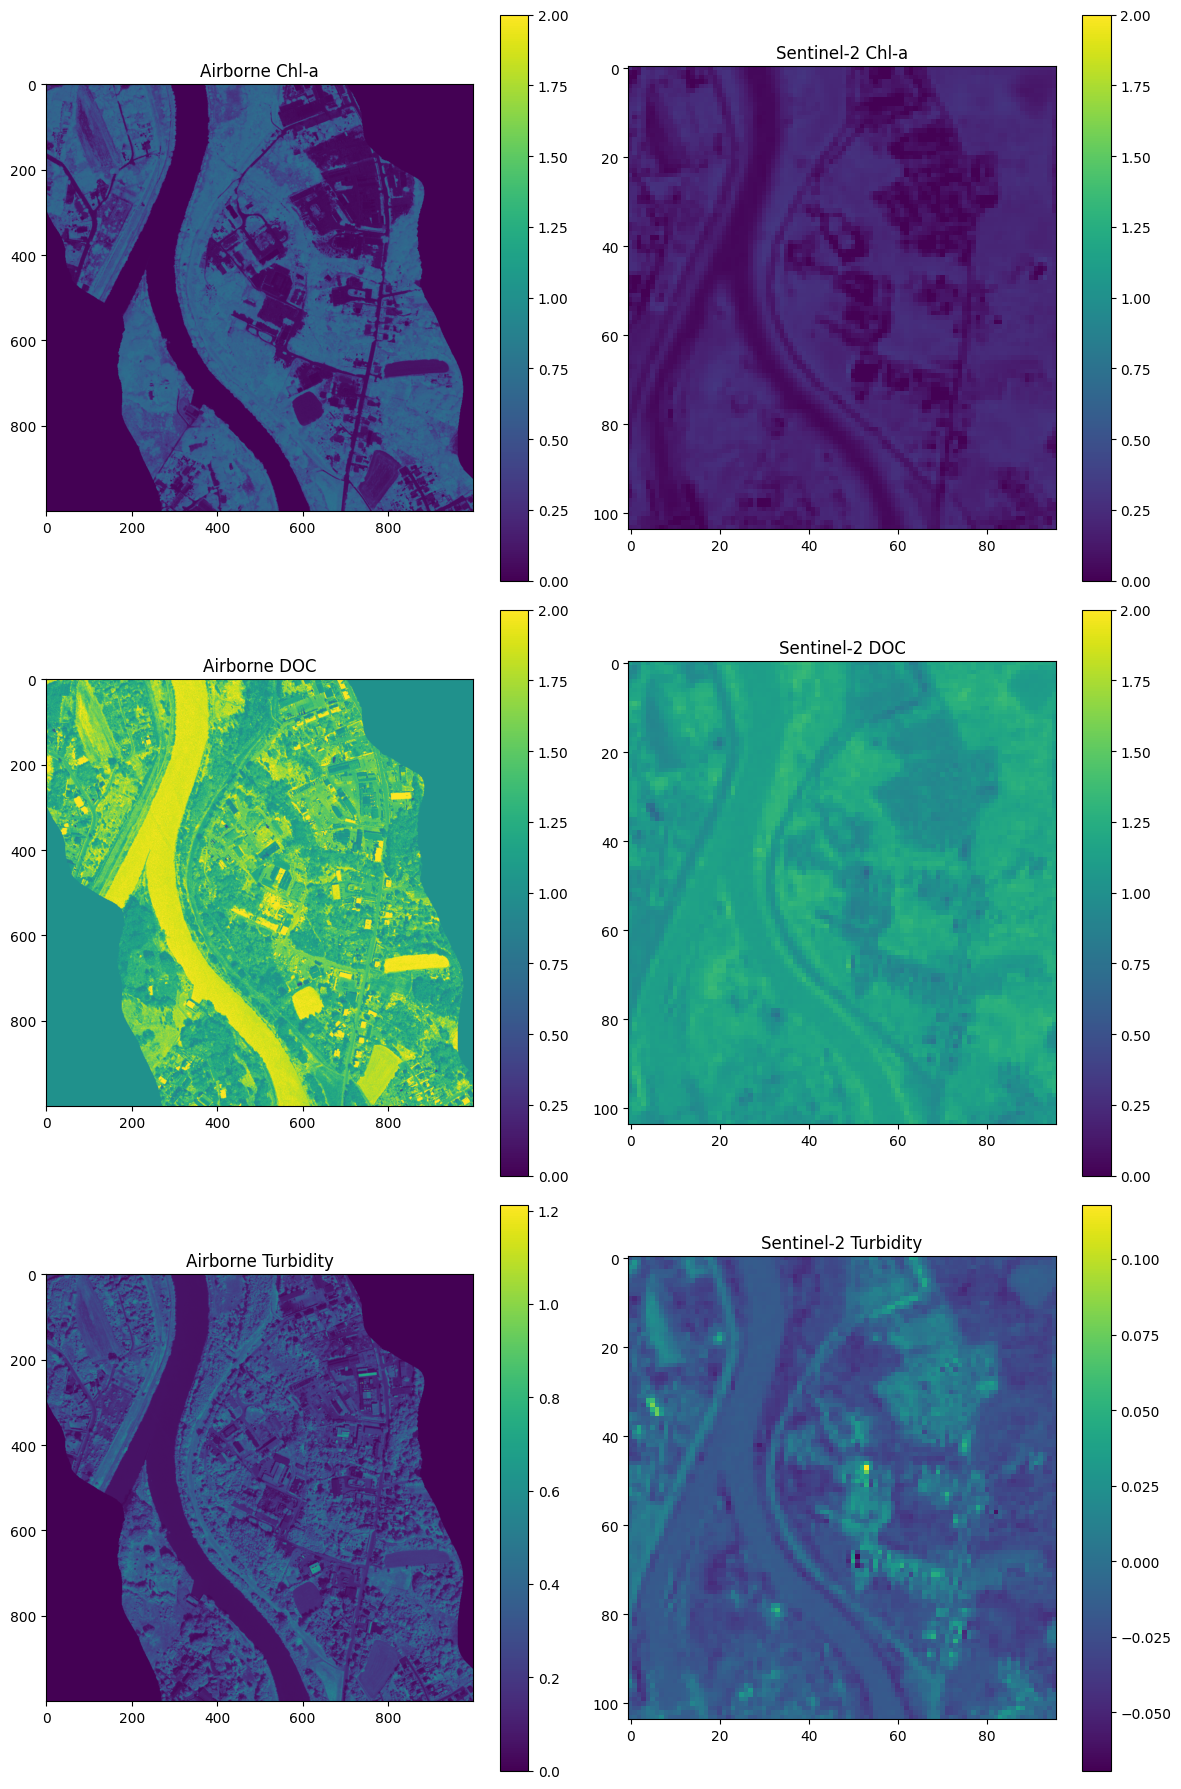

In [100]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

# Chl-a
im0 = axes[0, 0].imshow(chla_air, cmap='viridis', vmin=0, vmax=2)
axes[0, 0].set_title("Airborne Chl-a")
plt.colorbar(im0, ax=axes[0, 0])
im1 = axes[0, 1].imshow(chla_s2, cmap='viridis', vmin=0, vmax=2)
axes[0, 1].set_title("Sentinel-2 Chl-a")
plt.colorbar(im1, ax=axes[0, 1])

# DOC
im2 = axes[1, 0].imshow(doc_air, cmap='viridis', vmin=0, vmax=2)
axes[1, 0].set_title("Airborne DOC")
plt.colorbar(im2, ax=axes[1, 0])
im3 = axes[1, 1].imshow(doc_s2, cmap='viridis', vmin=0, vmax=2)
axes[1, 1].set_title("Sentinel-2 DOC")
plt.colorbar(im3, ax=axes[1, 1])

# Turbidity
im4 = axes[2, 0].imshow(turb_air, cmap='viridis')
axes[2, 0].set_title("Airborne Turbidity")
plt.colorbar(im4, ax=axes[2, 0])
im5 = axes[2, 1].imshow(turb_s2, cmap='viridis')
axes[2, 1].set_title("Sentinel-2 Turbidity")
plt.colorbar(im5, ax=axes[2, 1])

plt.tight_layout()
plt.show()